In [4]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from tqdm import tqdm
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
# Configuration
BATCH_SIZE = 64
NUM_EPOCHS = 10

CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]

LEARNING_RATE = 1e-4

IMAGE_SHAPE = (3, 240, 640)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


### Update for each circuit

In [6]:
TEST_CIRCUIT = CIRCUIT_LIST[3]
TEST_CIRCUIT

'nurburgring_circuit'

In [7]:
IS_BALANCED = True
CSE_FILE_NAME = ""
VERSION = 'v2'
if IS_BALANCED:
    CSV_FILE_NAME = f"balanced_train_{VERSION}.csv"
else: 
    CSV_FILE_NAME = "train.csv"
    
INPUT_BASE_DIR = ""
OUTPUT_DIR = ""

# make sure output_dir exist
os.makedirs(OUTPUT_DIR,exist_ok=True)

In [9]:
class FollowLineDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Optional: Validate required columns
        expected_columns = ['image', 'v', 'w']
        if len(self.annotations.columns) < 3:
            raise ValueError(f"CSV must have at least 3 columns: {expected_columns}")
        
    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()  # support Tensor indices
    
        # Get image name and velocity values
        img_name = self.annotations.iloc[idx, 0]
        linear_velocity = float(self.annotations.iloc[idx, 1])
        angular_velocity = float(self.annotations.iloc[idx, 2])
    
        # Optional: round to desired precision (e.g., 3 decimal places)
        linear_velocity = round(linear_velocity, 3)
        angular_velocity = round(angular_velocity, 3)
    
        # Load image
        img_path = os.path.join(self.root_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            raise FileNotFoundError(f"Image not found: {img_path}")
    
        if self.transform:
            image = self.transform(image)
    
        velocities = torch.tensor([linear_velocity, angular_velocity], dtype=torch.float32)
        return image, velocities

In [10]:
transform = transforms.Compose([
    transforms.Resize((240, 640)),
    transforms.ToTensor(),
])

train_dataset = FollowLineDataset(os.path.join(INPUT_BASE_DIR,CSV_FILE_NAME),os.path.join(INPUT_BASE_DIR,'train'), transform=transform)
test_dataset = FollowLineDataset(os.path.join(INPUT_BASE_DIR,"test.csv"), os.path.join(INPUT_BASE_DIR,'test'), transform=transform)


train_size = len(train_dataset)
test_size = len(test_dataset)

# train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [11]:

class PilotNet(nn.Module):
    def __init__(self):
        super(PilotNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU()
        )
        # Dynamically calculate flattened feature size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 240, 640)
            dummy_output = self.features(dummy_input)
            self.flattened_size = dummy_output.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2)  # Output: [v, w]
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [12]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PilotNet().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
train_losses = []
test_losses = []
# Training + Validation loop
for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * images.size(0)
    
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Test]"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            total_test_loss += loss.item() * images.size(0)

    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

# torch.save(model.state_dict(), 'model.pth')

Epoch 1/10 [Train]:  39%|████████▋             | 77/196 [00:35<00:54,  2.17it/s]

In [ ]:
import onnxruntime
dummy_input = torch.randn(1, 3, 240, 640).to(device)
onnx_path = f"{OUTPUT_DIR}/pilotnet_test_v1-{TEST_CIRCUIT}-balanced_v2.onnx"
torch.onnx.export(model, dummy_input, onnx_path,
                  input_names=['input'], output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
                  opset_version=11)
print(f"Exported model to {onnx_path}")


In [ ]:
import matplotlib.pyplot as plt

# Plotting loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), test_losses, label=f"Test Loss", marker='x')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'{TEST_CIRCUIT}-{VERSION} - Training vs Testing Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/{TEST_CIRCUIT}-{VERSION}-loss_curve.png")
plt.show()

In [ ]:

# ------------------ Evaluation Metrics ------------------
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        outputs = model(images)
        all_preds.append(outputs.cpu())
        all_targets.append(targets.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

mse_total = mean_squared_error(all_targets, all_preds)
mae_total = mean_absolute_error(all_targets, all_preds)
r2_total = r2_score(all_targets, all_preds)

mse_v = mean_squared_error(all_targets[:, 0], all_preds[:, 0])
mae_v = mean_absolute_error(all_targets[:, 0], all_preds[:, 0])
r2_v = r2_score(all_targets[:, 0], all_preds[:, 0])

mse_w = mean_squared_error(all_targets[:, 1], all_preds[:, 1])
mae_w = mean_absolute_error(all_targets[:, 1], all_preds[:, 1])
r2_w = r2_score(all_targets[:, 1], all_preds[:, 1])

print("\n--- Evaluation Metrics ---")
print(f"Combined - MSE: {mse_total:.4f}, MAE: {mae_total:.4f}, R2: {r2_total:.4f}")
print(f"Linear Velocity (v) - MSE: {mse_v:.4f}, MAE: {mae_v:.4f}, R2: {r2_v:.4f}")
print(f"Angular Velocity (w) - MSE: {mse_w:.4f}, MAE: {mae_w:.4f}, R2: {r2_w:.4f}")


## Full code v0.1

Using device: cuda


Epoch 1/5 [Test]: 100%|█████████████████████████| 45/45 [00:15<00:00,  2.90it/s]


Epoch 1: Train Loss = 4.0195, Test Loss = 1.0349


Epoch 2/5 [Test]: 100%|█████████████████████████| 45/45 [00:13<00:00,  3.25it/s]


Epoch 2: Train Loss = 0.7351, Test Loss = 0.7212


...

Epoch 3: Train Loss = 0.4607, Test Loss = 0.5646


Epoch 4/5 [Test]: 100%|█████████████████████████| 45/45 [00:14<00:00,  3.09it/s]


Epoch 4: Train Loss = 0.3178, Test Loss = 0.3767


Epoch 5/5 [Test]: 100%|█████████████████████████| 45/45 [00:14<00:00,  3.10it/s]


Epoch 5: Train Loss = 0.2802, Test Loss = 0.3358
Exported model to /home/codezerro/Desktop/models/test_pilotnet_test_v1-montmelo_circuit-balanced_v1.onnx


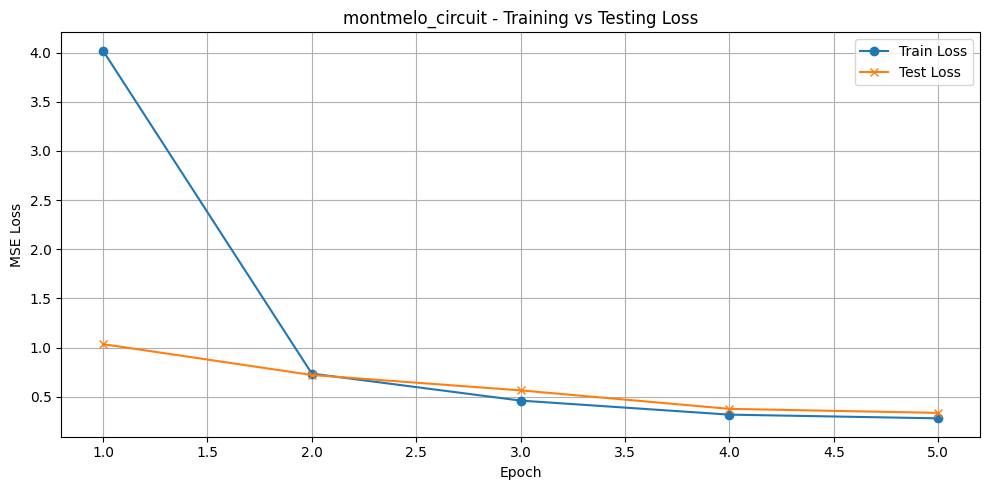

Evaluating: 100%|███████████████████████████████| 45/45 [00:16<00:00,  2.79it/s]


--- Evaluation Metrics ---
Combined - MSE: 0.3358, MAE: 0.3271, R2: 0.8140
Linear Velocity (v) - MSE: 0.6121, MAE: 0.4884, R2: 0.8296
Angular Velocity (w) - MSE: 0.0595, MAE: 0.1657, R2: 0.7984


In [1]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------ Configuration ------------------
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-4
IMAGE_SHAPE = (3, 240, 640)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]
TEST_CIRCUIT = CIRCUIT_LIST[2]  # montmelo_circuit

IS_BALANCED = True
CSV_FILE_NAME = "balanced_train.csv" if IS_BALANCED else "train.csv"
INPUT_BASE_DIR = ""
OUTPUT_DIR = "" 

# ------------------ Dataset Class ------------------
class FollowLineDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.annotations.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        linear_velocity = float(self.annotations.iloc[idx, 1])
        angular_velocity = float(self.annotations.iloc[idx, 2])
        return image, torch.tensor([linear_velocity, angular_velocity], dtype=torch.float32)

# ------------------ Transforms & Loaders ------------------
transform = transforms.Compose([
    transforms.Resize((240, 640)),
    transforms.ToTensor(),
])

train_dataset = FollowLineDataset(os.path.join(INPUT_BASE_DIR, CSV_FILE_NAME), os.path.join(INPUT_BASE_DIR, 'train'), transform=transform)
test_dataset = FollowLineDataset(os.path.join(INPUT_BASE_DIR, "test.csv"), os.path.join(INPUT_BASE_DIR, 'test'), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ------------------ PilotNet Model ------------------
class PilotNet(nn.Module):
    def __init__(self):
        super(PilotNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU()
        )
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 240, 640)
            dummy_output = self.features(dummy_input)
            self.flattened_size = dummy_output.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# ------------------ Training ------------------
model = PilotNet().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
test_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * images.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Test]"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            total_test_loss += loss.item() * images.size(0)

    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

# ------------------ Export ONNX ------------------
dummy_input = torch.randn(1, 3, 240, 640).to(DEVICE)
onnx_path = f"{OUTPUT_DIR}/test_pilotnet_test_v1-{TEST_CIRCUIT}-balanced_v1.onnx"
torch.onnx.export(model, dummy_input, onnx_path,
                  input_names=['input'], output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
                  opset_version=11)
print(f"Exported model to {onnx_path}")

# ------------------ Plotting Loss Curve ------------------
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), test_losses, label='Test Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'{TEST_CIRCUIT} - Training vs Testing Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{TEST_CIRCUIT}-loss_curve.png")
plt.show()

# ------------------ Evaluation Metrics ------------------
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        outputs = model(images)
        all_preds.append(outputs.cpu())
        all_targets.append(targets.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

mse_total = mean_squared_error(all_targets, all_preds)
mae_total = mean_absolute_error(all_targets, all_preds)
r2_total = r2_score(all_targets, all_preds)

mse_v = mean_squared_error(all_targets[:, 0], all_preds[:, 0])
mae_v = mean_absolute_error(all_targets[:, 0], all_preds[:, 0])
r2_v = r2_score(all_targets[:, 0], all_preds[:, 0])

mse_w = mean_squared_error(all_targets[:, 1], all_preds[:, 1])
mae_w = mean_absolute_error(all_targets[:, 1], all_preds[:, 1])
r2_w = r2_score(all_targets[:, 1], all_preds[:, 1])

print("\n--- Evaluation Metrics ---")
print(f"Combined - MSE: {mse_total:.4f}, MAE: {mae_total:.4f}, R2: {r2_total:.4f}")
print(f"Linear Velocity (v) - MSE: {mse_v:.4f}, MAE: {mae_v:.4f}, R2: {r2_v:.4f}")
print(f"Angular Velocity (w) - MSE: {mse_w:.4f}, MAE: {mae_w:.4f}, R2: {r2_w:.4f}")


In [2]:
# all_targets

In [4]:
from sklearn.linear_model import LinearRegression
from scipy.ndimage import gaussian_filter1d
import numpy as np
# ------------------ Post-processing ------------------

# Rescale v
v_scaler = LinearRegression()
v_scaler.fit(all_preds[:, 0].reshape(-1, 1), all_targets[:, 0])
adjusted_v = v_scaler.predict(all_preds[:, 0].reshape(-1, 1))

# Rescale w
w_scaler = LinearRegression()
w_scaler.fit(all_preds[:, 1].reshape(-1, 1), all_targets[:, 1])
adjusted_w = w_scaler.predict(all_preds[:, 1].reshape(-1, 1))

# Smoothing using Gaussian filter
smoothed_v = gaussian_filter1d(adjusted_v, sigma=1)
smoothed_w = gaussian_filter1d(adjusted_w, sigma=1)

# Combine final outputs
final_outputs = np.stack([smoothed_v, smoothed_w], axis=1)

# ------------------ Final Metrics After Post-Processing ------------------

mse_total_adj = mean_squared_error(all_targets, final_outputs)
mae_total_adj = mean_absolute_error(all_targets, final_outputs)
r2_total_adj = r2_score(all_targets, final_outputs)

mse_v_adj = mean_squared_error(all_targets[:, 0], final_outputs[:, 0])
mae_v_adj = mean_absolute_error(all_targets[:, 0], final_outputs[:, 0])
r2_v_adj = r2_score(all_targets[:, 0], final_outputs[:, 0])

mse_w_adj = mean_squared_error(all_targets[:, 1], final_outputs[:, 1])
mae_w_adj = mean_absolute_error(all_targets[:, 1], final_outputs[:, 1])
r2_w_adj = r2_score(all_targets[:, 1], final_outputs[:, 1])

print("\n--- Evaluation Metrics After Rescaling + Smoothing ---")
print(f"Combined - MSE: {mse_total_adj:.4f}, MAE: {mae_total_adj:.4f}, R2: {r2_total_adj:.4f}")
print(f"Linear Velocity (v) - MSE: {mse_v_adj:.4f}, MAE: {mae_v_adj:.4f}, R2: {r2_v_adj:.4f}")
print(f"Angular Velocity (w) - MSE: {mse_w_adj:.4f}, MAE: {mae_w_adj:.4f}, R2: {r2_w_adj:.4f}")

# Optional: Save final output
np.save(os.path.join(OUTPUT_DIR, f"{TEST_CIRCUIT}_final_predictions.npy"), final_outputs)



--- Evaluation Metrics After Rescaling + Smoothing ---
Combined - MSE: 0.2967, MAE: 0.3020, R2: 0.8311
Linear Velocity (v) - MSE: 0.5380, MAE: 0.4471, R2: 0.8502
Angular Velocity (w) - MSE: 0.0555, MAE: 0.1569, R2: 0.8120


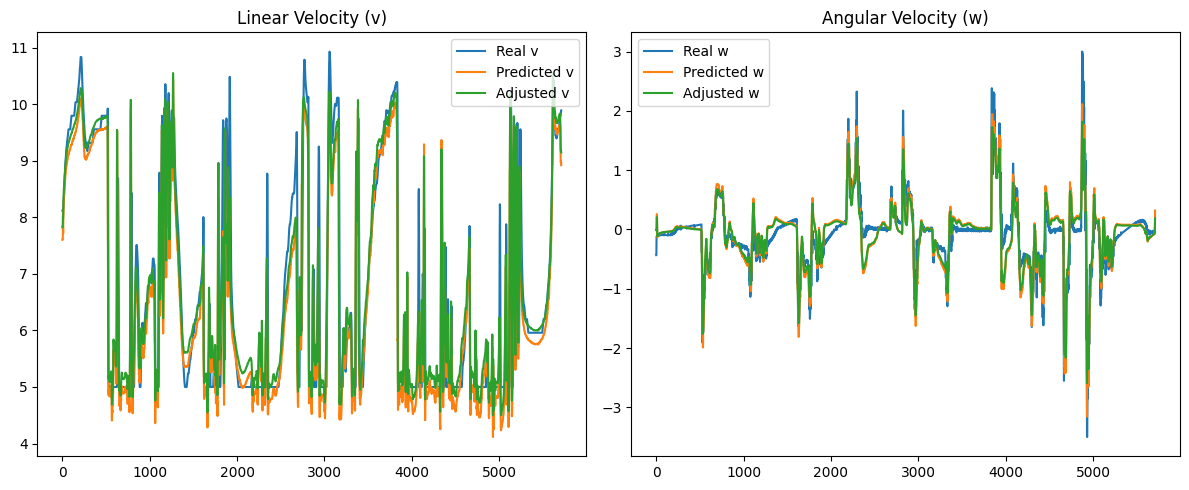

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(all_targets[:, 0], label="Real v")
plt.plot(all_preds[:, 0], label="Predicted v")
plt.plot(final_outputs[:, 0], label="Adjusted v")
plt.legend()
plt.title("Linear Velocity (v)")

plt.subplot(1, 2, 2)
plt.plot(all_targets[:, 1], label="Real w")
plt.plot(all_preds[:, 1], label="Predicted w")
plt.plot(final_outputs[:, 1], label="Adjusted w")
plt.legend()
plt.title("Angular Velocity (w)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{TEST_CIRCUIT}_adjusted_output_plot.png"))
plt.show()


In [6]:
from sklearn.linear_model import LinearRegression

# Rescale v
v_scaler = LinearRegression()
v_scaler.fit(all_preds[:, 0].reshape(-1, 1), all_targets[:, 0])

# Rescale w
w_scaler = LinearRegression()
w_scaler.fit(all_preds[:, 1].reshape(-1, 1), all_targets[:, 1])


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
v_alpha = v_scaler.coef_[0]        # Slope for v
v_beta = v_scaler.intercept_       # Intercept for v

w_alpha = w_scaler.coef_[0]        # Slope for w
w_beta = w_scaler.intercept_       # Intercept for w

print("v_alpha:", v_alpha)
print("v_beta:", v_beta)
print("w_alpha:", w_alpha)
print("w_beta:", w_beta)


v_alpha: 0.98717344
v_beta: 0.31721735
w_alpha: 0.893452
w_beta: -0.0064588487
